# 05 · Orquestación y ablación: ¿cuánto aporta cada modelo y cada modalidad?

Es el argumento central del proyecto: **combinar modelos y modalidades supera a cualquiera por separado**.
Lo comprobamos con un estudio de ablación sobre casos multimodales y ajustamos los pesos de la fusión.

**Casos.** Convertimos los 60 mensajes del test escrito a mano (notebook 01) en casos **multimodales
reales**:

* los SMS, WhatsApp, correos y webs se **renderizan como capturas** (el sistema solo ve la imagen y tiene
  que leerla con Qwen2.5-VL);
* las transcripciones de llamadas se **locutan** con MMS-TTS y pasan por el canal telefónico simulado (el
  sistema solo ve el audio y tiene que transcribirlo con Whisper).

Los metadatos (remitente, hora) son **idénticos** para estafas y legítimos, para que el remitente no
delate la etiqueta. Ninguno de estos textos se usó para entrenar.

**Señales** que recoge el orquestador (`src/diputado/core/pipeline.py`) para cada caso:

| Señal | Modelo | Modalidad de origen |
|---|---|---|
| `tacticnet` | e5 + TacticNet (Keras) | Texto (leído de la imagen o transcrito) |
| `llm` | Qwen3 8B | Texto + contexto visual |
| `reglas` | Regex + rapidfuzz | Texto + enlaces leídos por el VLM |
| `campana` | e5 + SigLIP2 | Texto **e imagen** |
| `voz`, `acustica` | CLAP + VozSinteticaNet (Keras) | Audio |

In [1]:
import json
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from diputado import config

config.ensure_dirs()
config.ensure_ffmpeg_on_path()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Markdown, display
from scipy.optimize import minimize
from sklearn.metrics import brier_score_loss, confusion_matrix, f1_score, roc_auc_score

from diputado.ai import ollama_server
from diputado.core import fusion, pipeline
from diputado.core.schemas import CaseInput
from diputado.media import render

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ollama_server.ensure_server(install_if_missing=False)
pipeline._store = lambda r: None  # no mezclamos estos experimentos con el histórico de la consola

## 1. Construcción de los casos multimodales

In [2]:
from diputado.ai import tts
from diputado.ai.audio_io import resample
from diputado.data.telephony import phone_channel

test = pd.read_csv(config.DATA_DIR / "test_manual.csv")
case_dir = config.SYNTHETIC_DIR / "ablacion"
case_dir.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)
cases = []
for i, r in test.iterrows():
    if r["canal"] == "llamada":
        p = case_dir / f"caso_{i:02d}.wav"
        if not p.exists():
            audio, sr = tts.synthesize(r["texto"], seed=i)
            sf.write(p, phone_channel(resample(audio, sr, 16000), 16000, rng), 16000)
        cases.append({"i": i, "audio": str(p), "imagen": None})
    else:
        p = case_dir / f"caso_{i:02d}.png"
        if not p.exists():
            if r["canal"] == "whatsapp":
                img = render.render_whatsapp("Contacto", r["texto"], hour="12:00", unknown=False)
            elif r["canal"] == "email":
                img = render.render_email("notificaciones@correo.es", "Aviso", r["texto"], hour="12:00")
            elif r["canal"] == "web":
                img = render.render_web("Página web", r["texto"])
            else:
                img = render.render_sms("Aviso", r["texto"], hour="12:00")
            render.save(img, p)
        cases.append({"i": i, "audio": None, "imagen": str(p)})
print(f"{len(cases)} casos · {sum(c['audio'] is not None for c in cases)} llamadas · {sum(c['imagen'] is not None for c in cases)} capturas")

60 casos · 11 llamadas · 49 capturas


## 2. Ejecución del orquestador completo sobre cada caso

Guardamos en caché (`artifacts/ablacion_senales.csv`) las señales de cada caso para que el resto del
notebook (y quien lo reproduzca) no tenga que repetir la inferencia, que en un portátil de 8 GB dura más de
una hora porque cada captura obliga a turnar en la GPU el modelo de visión y el de razonamiento.

In [3]:
CACHE = config.ARTIFACTS_DIR / "ablacion_senales.csv"
done = pd.read_csv(CACHE) if CACHE.exists() else pd.DataFrame()
rows = done.to_dict("records")
seen = set(done["i"]) if len(done) else set()
t0 = time.perf_counter()
for c in cases:
    if c["i"] in seen:
        continue
    r = pipeline.run(CaseInput(image=c["imagen"], audio=c["audio"], source="ablacion"))
    camp = r.campaigns[0] if r.campaigns else {}
    rows.append({
        "i": c["i"], "modalidad": "audio" if c["audio"] else "imagen",
        "tacticnet": (r.tactic_model or {}).get("scam_prob"), "llm": (r.llm or {}).get("probabilidad_estafa"),
        "reglas": fusion.rules_to_prob(r.extract["red_flag_score"]) if r.extract else None,
        "campana": fusion.campaign_to_prob(camp["similitud"]) if camp else None,
        "campana_texto": camp.get("detalle", {}).get("texto"), "campana_imagen": camp.get("detalle", {}).get("imagen"),
        "voz": (r.voice or {}).get("synthetic_prob"),
        "acustica": (r.acoustic or {}).get("Voz robótica o sintética", 0) + (r.acoustic or {}).get("Menú automático (IVR)", 0) if r.acoustic else None,
        "regla_dura": bool(r.extract and r.extract["hard_rule"]),
        "riesgo_app": r.risk, "nivel_app": r.level, "ms": r.total_ms(), "errores": "; ".join(r.errors),
        "texto_leido": r.evidence_text[:300],
    })
    pd.DataFrame(rows).to_csv(CACHE, index=False)
print(f"Inferencia: {time.perf_counter() - t0:.0f} s")
S = pd.DataFrame(rows).sort_values("i").reset_index(drop=True)
S["estafa"] = test.loc[S["i"], "estafa"].values
S["canal"] = test.loc[S["i"], "canal"].values
print("Casos con errores:", (S["errores"].fillna("") != "").sum())
display(S.head())

Inferencia: 0 s
Casos con errores: 0


,i,modalidad,tacticnet,llm,reglas,campana,campana_texto,campana_imagen,voz,acustica,regla_dura,riesgo_app,nivel_app,ms,errores,texto_leido,estafa,canal
0,0,imagen,0.625670,0.20,0.2000,0.590520,0.864814,0.828727,NaN,NaN,False,0.117809,verde,129805.4,NaN,Remitente: CaixaSur\nCaixaSur: se ha registrad...,1,sms
1,1,imagen,0.966149,0.95,0.4625,0.950000,0.906958,0.944573,NaN,NaN,False,0.999393,rojo,73060.4,NaN,Remitente: A\nSu envio no ha podido ser entreg...,1,sms
2,2,imagen,0.024293,0.95,0.3875,0.300000,0.864528,0.862924,NaN,NaN,False,0.189402,verde,78194.4,NaN,"Remitente: Contacto\nHola papa, este es mi num...",1,whatsapp
3,3,imagen,0.105236,0.98,0.3125,0.365891,0.907458,0.903451,NaN,NaN,False,0.691000,rojo,82577.4,NaN,"Remitente: Contacto\nmama soy yo, tengo un pro...",1,whatsapp
4,4,audio,0.833667,0.95,0.4625,0.320073,0.901368,NaN,0.900006,0.687439,True,0.984815,rojo,73932.0,NaN,Le llamo de la unidad antifraude de su entidad...,1,llamada


## 3. Cada señal por separado

In [4]:
SIGNALS = ["tacticnet", "llm", "reglas", "campana", "voz", "acustica"]
y = S["estafa"].values


def metrics(p, y_true=None, mask=None):
    y_true = y if y_true is None else y_true
    if mask is not None:
        p, y_true = p[mask], y_true[mask]
    ok = ~np.isnan(p)
    p, y_true = p[ok], y_true[ok]
    if len(np.unique(y_true)) < 2:
        return {"n": len(p), "AUC": np.nan, "F1": np.nan, "Brier": np.nan}
    return {"n": len(p), "AUC": roc_auc_score(y_true, p), "F1": f1_score(y_true, p >= 0.5), "Brier": brier_score_loss(y_true, np.clip(p, 0, 1))}


single = pd.DataFrame({s: metrics(S[s].astype(float).values) for s in SIGNALS}).T
single.index = [fusion.SIGNAL_LABELS[s] for s in single.index]
display(single.round(3))

,n,AUC,F1,Brier
"TacticNet (Keras, texto)",60.0,0.910,0.882,0.120
Qwen3 (razonamiento),60.0,0.932,0.921,0.090
Reglas deterministas,60.0,0.756,0.364,0.271
Parecido a campañas conocidas,60.0,0.531,0.508,0.323
"VozSinteticaNet (Keras, audio)",11.0,0.250,0.778,0.302
Contexto acústico (CLAP),11.0,0.000,0.842,0.292


## 4. Fusión: pesos iniciales frente a pesos ajustados

El riesgo es `sigmoide(b + Σ w_i · logit(p_i))`. Ajustamos `b` y `w` minimizando la log-loss con
regularización L2 y **pesos no negativos** (una señal de fraude nunca debe restar riesgo por ser alta).
Las señales de audio son **amplificadoras**: antes del logit las recortamos a ≥ 0,5, igual que en la
aplicación. Para no evaluarnos con los mismos datos con los que ajustamos, usamos **validación cruzada
dejando uno fuera** (LOO): cada caso se predice con pesos ajustados sin él.

In [5]:
def features(df, names):
    F = np.zeros((len(df), len(names)))
    for j, n in enumerate(names):
        p = df[n].astype(float).values
        if n in fusion.AMPLIFIERS:
            p = np.where(np.isnan(p), np.nan, np.maximum(p, 0.5))
        F[:, j] = np.where(np.isnan(p), 0.0, [fusion.logit(v) if not np.isnan(v) else 0 for v in p])
    return F


def fit(F, yy, l2=0.5):
    def loss(theta):
        z = theta[0] + F @ theta[1:]
        p = 1 / (1 + np.exp(-z))
        p = np.clip(p, 1e-6, 1 - 1e-6)
        return -np.mean(yy * np.log(p) + (1 - yy) * np.log(1 - p)) + l2 * np.sum(theta[1:] ** 2) / len(yy)
    x0 = np.r_[0.0, np.full(F.shape[1], 0.5)]
    res = minimize(loss, x0, bounds=[(-3, 3)] + [(0, 3)] * F.shape[1], method="L-BFGS-B")
    return res.x


def predict(theta, F):
    return 1 / (1 + np.exp(-(theta[0] + F @ theta[1:])))


def loo(names, l2=0.5):
    F = features(S, names)
    out = np.zeros(len(S))
    for k in range(len(S)):
        m = np.arange(len(S)) != k
        out[k] = predict(fit(F[m], y[m], l2), F[k:k + 1])[0]
    return out


def default_fusion(names, hard=True):
    return np.array([fusion.fuse({n: (None if pd.isna(row[n]) else float(row[n])) for n in names},
                                 hard_rule=hard and row["regla_dura"], params=fusion.DEFAULT).risk for _, row in S.iterrows()])


combos = {
    "Solo TacticNet": ["tacticnet"],
    "Solo Qwen3": ["llm"],
    "Solo reglas": ["reglas"],
    "Texto: TacticNet + Qwen3": ["tacticnet", "llm"],
    "Texto: TacticNet + Qwen3 + reglas": ["tacticnet", "llm", "reglas"],
    "Texto + campañas (texto e imagen)": ["tacticnet", "llm", "reglas", "campana"],
    "Todo (texto + imagen + audio)": SIGNALS,
}
abl = []
for name, names in combos.items():
    abl.append({"configuración": name, "pesos": "iniciales", **metrics(default_fusion(names, hard=False))})
    abl.append({"configuración": name, "pesos": "ajustados (LOO)", **metrics(loo(names))})
abl.append({"configuración": "Todo + regla dura (aplicación)", "pesos": "iniciales", **metrics(default_fusion(SIGNALS))})
abl = pd.DataFrame(abl)
display(abl.pivot(index="configuración", columns="pesos", values=["AUC", "F1", "Brier"]).reindex(list(combos) + ["Todo + regla dura (aplicación)"]).round(3))

AUC                        F1  \
pesos                             ajustados (LOO) iniciales ajustados (LOO)   
configuración                                                                 
Solo TacticNet                              0.899     0.910           0.873   
Solo Qwen3                                  0.870     0.932           0.921   
Solo reglas                                 0.655     0.756           0.767   
Texto: TacticNet + Qwen3                    0.958     0.969           0.932   
Texto: TacticNet + Qwen3 + reglas           0.956     0.972           0.904   
Texto + campañas (texto e imagen)           0.949     0.975           0.892   
Todo (texto + imagen + audio)               0.949     0.975           0.892   
Todo + regla dura (aplicación)                NaN     0.975             NaN   

                                                      Brier            
pesos                             iniciales ajustados (LOO) iniciales  
configuración                                                          
Solo TacticNet                        0.866           0.120     0.124  
Solo Qwen3                            0.921           0.091     0.088  
Solo reglas                           0.154           0.205     0.284  
Texto: TacticNet + Qwen3              0.919           0.084     0.071  
Texto: TacticNet + Qwen3 + reglas     0.917           0.085     0.072  
Texto + campañas (texto e imagen)     0.919           0.090     0.072  
Todo (texto + imagen + audio)         0.919           0.091     0.072  
Todo + regla dura (aplicación)        0.919             NaN     0.072

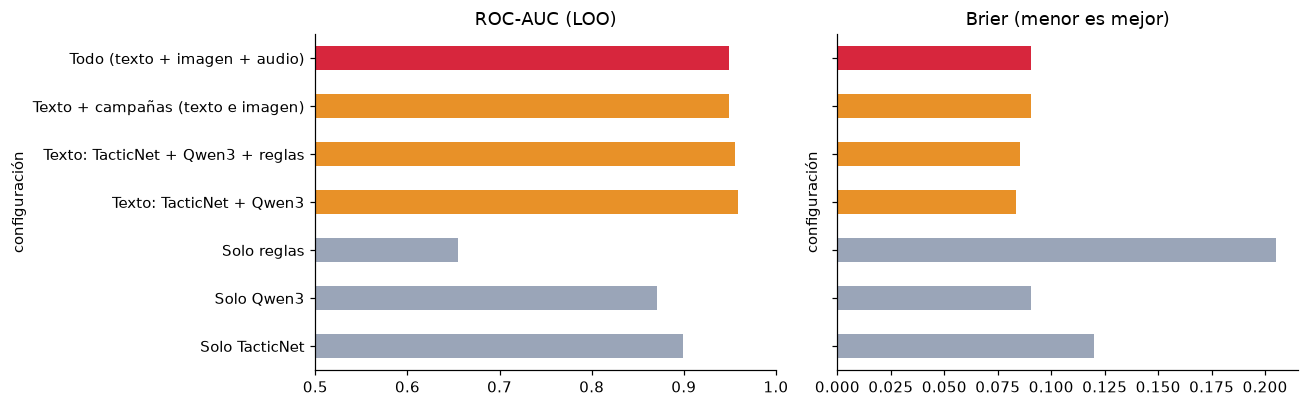

In [6]:
plot = abl[abl["pesos"] == "ajustados (LOO)"].set_index("configuración")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot["AUC"].plot.barh(ax=axes[0], color=["#9aa5b8"] * 3 + ["#e89128"] * 3 + ["#d7263d"])
axes[0].set_xlim(0.5, 1); axes[0].set_title("ROC-AUC (LOO)")
plot["Brier"].plot.barh(ax=axes[1], color=["#9aa5b8"] * 3 + ["#e89128"] * 3 + ["#d7263d"])
axes[1].set_title("Brier (menor es mejor)"); axes[1].set_yticklabels([])
plt.tight_layout()

### ¿Es significativa la mejora? Bootstrap pareado

Con 60 casos las diferencias pueden ser ruido. Remuestreamos los casos 2.000 veces y calculamos el
intervalo de confianza del 95 % de la diferencia entre el sistema fusionado y el mejor modelo individual.
Comparamos dos versiones de la fusión, ambas sin haber visto el caso que predicen:

* **pesos a priori**: los que fijamos razonando antes de este experimento (`fusion.DEFAULT`), con la regla dura;
* **pesos ajustados (LOO)**: reajustados en cada iteración sin el caso evaluado.

In [7]:
best_single = min(["tacticnet", "llm", "reglas"], key=lambda s: brier_score_loss(y, np.nan_to_num(S[s].astype(float).values, nan=0.5)))
p_best = np.nan_to_num(S[best_single].astype(float).values, nan=0.5)
candidates = {"a_priori": default_fusion(SIGNALS), "loo": loo(SIGNALS)}


def paired_bootstrap(p_sys, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    d_brier, d_auc = [], []
    for _ in range(n):
        b = rng.integers(0, len(y), len(y))
        if len(np.unique(y[b])) < 2:
            continue
        d_brier.append(brier_score_loss(y[b], p_best[b]) - brier_score_loss(y[b], p_sys[b]))
        d_auc.append(roc_auc_score(y[b], p_sys[b]) - roc_auc_score(y[b], p_best[b]))
    stat = lambda d: [round(float(np.mean(d)), 4), *[round(float(v), 4) for v in np.percentile(d, [2.5, 97.5])]]  # noqa: E731
    return {"mejora_brier": stat(d_brier), "mejora_auc": stat(d_auc)}


boot = {k: paired_bootstrap(p) for k, p in candidates.items()}
names = {"a_priori": "Fusión con pesos a priori", "loo": "Fusión con pesos ajustados (LOO)"}
display(Markdown(f"Mejor señal individual: **{fusion.SIGNAL_LABELS[best_single]}**. Mejora frente a ella "
                 "(positivo = mejor la fusión; IC 95 % entre paréntesis):\n\n| Sistema | Brier | AUC |\n|---|---|---|\n" + "\n".join(
                     f"| {names[k]} | {v['mejora_brier'][0]:+.3f} ({v['mejora_brier'][1]:+.3f} a {v['mejora_brier'][2]:+.3f}) | "
                     f"{v['mejora_auc'][0]:+.3f} ({v['mejora_auc'][1]:+.3f} a {v['mejora_auc'][2]:+.3f}) |" for k, v in boot.items())))

Mejor señal individual: **Qwen3 (razonamiento)**. Mejora frente a ella (positivo = mejor la fusión; IC 95 % entre paréntesis):

| Sistema | Brier | AUC |
|---|---|---|
| Fusión con pesos a priori | +0.018 (-0.025 a +0.064) | +0.042 (-0.004 a +0.099) |
| Fusión con pesos ajustados (LOO) | -0.001 (-0.039 a +0.037) | +0.017 (-0.035 a +0.071) |

## 5. Pesos finales y exportación a `artifacts/fusion.json`

Ajustamos con todos los casos. Para no sobreajustar a 60 casos, **mezclamos** los pesos ajustados con
los iniciales razonados (media 50/50): es una forma simple de regularización hacia un *prior* experto.
Las métricas con estos pesos finales se calculan sobre los mismos casos con los que se han ajustado en
parte, así que son **optimistas**; las comparaciones justas son las de la tabla anterior.

In [8]:
F_all = features(S, SIGNALS)
theta = fit(F_all, y)
fitted = dict(zip(SIGNALS, theta[1:]))
blend = {s: round(0.5 * fitted[s] + 0.5 * fusion.DEFAULT["weights"][s], 3) for s in SIGNALS}
bias = round(0.5 * theta[0] + 0.5 * fusion.DEFAULT["bias"], 3)
wt = pd.DataFrame({"iniciales": fusion.DEFAULT["weights"], "ajustados": {k: round(v, 3) for k, v in fitted.items()}, "finales (mezcla)": blend})
wt.index = [fusion.SIGNAL_LABELS[s] for s in wt.index]
display(wt)
print(f"Sesgo: inicial {fusion.DEFAULT['bias']} · ajustado {theta[0]:.3f} · final {bias}")

params = {"bias": bias, "weights": blend, "source": f"notebook 05: mezcla 50/50 de pesos ajustados ({len(S)} casos multimodales) y pesos iniciales"}
p_final = np.array([fusion.fuse({n: (None if pd.isna(row[n]) else float(row[n])) for n in SIGNALS}, hard_rule=row["regla_dura"], params=params).risk
                    for _, row in S.iterrows()])
print("Con los pesos finales:", {k: round(v, 3) for k, v in metrics(p_final).items()})
(config.ARTIFACTS_DIR / "fusion.json").write_text(json.dumps(params, ensure_ascii=False, indent=2), encoding="utf-8")

,iniciales,ajustados,finales (mezcla)
"TacticNet (Keras, texto)",0.90,0.575,0.737
Qwen3 (razonamiento),1.00,0.810,0.905
Parecido a campañas conocidas,0.60,0.086,0.343
Reglas deterministas,0.80,0.287,0.544
"VozSinteticaNet (Keras, audio)",0.25,0.237,0.244
Contexto acústico (CLAP),0.00,0.132,0.066


Sesgo: inicial -0.2 · ajustado -0.487 · final -0.343
Con los pesos finales: {'n': 60, 'AUC': 0.973, 'F1': 0.932, 'Brier': 0.068}


267

## 6. El semáforo: tres niveles

La aplicación no da una probabilidad, da un **semáforo**: verde (< 0,35), ámbar (0,35-0,65) y rojo (≥ 0,65).
El ámbar es deliberado: es mejor decir «compruébalo» que equivocarse con seguridad.

In [9]:
levels = np.array([fusion.level_for(p) for p in p_final])
tab = pd.crosstab(pd.Series(np.where(y == 1, "estafa", "legítimo"), name="real"), pd.Series(levels, name="semáforo"))
display(tab.reindex(columns=["verde", "ambar", "rojo"], fill_value=0))
fn = ((y == 1) & (levels == "verde")).sum()
fp = ((y == 0) & (levels == "rojo")).sum()
display(Markdown(f"**Errores graves:** {fn} estafas en verde y {fp} legítimos en rojo, de {len(y)} casos."))

semáforo,verde,ambar,rojo
real,,,
estafa,2,1,33
legítimo,20,2,2


**Errores graves:** 2 estafas en verde y 2 legítimos en rojo, de 60 casos.

In [10]:
S["riesgo_final"] = p_final
S["nivel_final"] = levels
bad = S[((S["estafa"] == 1) & (S["nivel_final"] != "rojo")) | ((S["estafa"] == 0) & (S["nivel_final"] != "verde"))]
display(bad[["i", "canal", "estafa", "nivel_final", "riesgo_final", "tacticnet", "llm", "reglas", "texto_leido"]].round(2))

,i,canal,estafa,nivel_final,riesgo_final,tacticnet,llm,reglas,texto_leido
0,0,sms,1,verde,0.14,0.63,0.20,0.20,Remitente: CaixaSur\nCaixaSur: se ha registrad...
2,2,whatsapp,1,verde,0.28,0.02,0.95,0.39,"Remitente: Contacto\nHola papa, este es mi num..."
15,15,whatsapp,1,ambar,0.61,0.12,0.95,0.31,Remitente: Contacto\nbuenas te escribo por lo ...
37,37,sms,0,ambar,0.47,0.03,0.95,0.20,Remitente: A\nTu código de verificación es 482...
44,44,whatsapp,0,ambar,0.63,0.27,0.95,0.20,"Remitente: Contacto\nChicas, para el regalo de..."
53,53,sms,0,rojo,0.91,0.89,0.85,0.31,Remitente: Aviso\nSu transferencia de 300 EUR ...
56,56,sms,0,rojo,0.85,0.29,0.95,0.31,Remitente: A\nTu código de acceso a la sede el...


## 7. Por modalidad de entrada

In [11]:
by_mod = pd.DataFrame({m: metrics(p_final, mask=(S["modalidad"] == m).values) for m in ("imagen", "audio")}).T
display(by_mod.round(3))
print(f"Latencia media del análisis: imagen {S.loc[S.modalidad == 'imagen', 'ms'].mean() / 1000:.1f} s · "
      f"audio {S.loc[S.modalidad == 'audio', 'ms'].mean() / 1000:.1f} s")

,n,AUC,F1,Brier
imagen,49.0,0.964,0.912,0.083
audio,11.0,1.000,1.000,0.003


Latencia media del análisis: imagen 67.8 s · audio 34.6 s


In [12]:
summary = {"casos": len(S), "senales_individuales": single.round(4).to_dict(orient="index"),
           "ablacion": abl.round(4).to_dict(orient="records"),
           "bootstrap": {"mejor_individual": best_single, **boot},
           "semaforo": tab.to_dict(), "final": {k: round(float(v), 4) for k, v in metrics(p_final).items()},
           "latencia_media_s": {m: round(float(S.loc[S.modalidad == m, "ms"].mean() / 1000), 1) for m in ("imagen", "audio")}}
(config.ARTIFACTS_DIR / "ablacion.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

4134

## Conclusiones

In [13]:
row = lambda c: abl[(abl["configuración"] == c) & (abl["pesos"] == "iniciales")].iloc[0]  # noqa: E731
q, t, allp = row("Solo Qwen3"), row("Solo TacticNet"), row("Todo + regla dura (aplicación)")
ap, lo_ = boot["a_priori"], boot["loo"]
sig = lambda ci: ci[1] > 0  # noqa: E731
audio_auc = single.loc[[fusion.SIGNAL_LABELS["voz"], fusion.SIGNAL_LABELS["acustica"]], "AUC"]
display(Markdown("\n".join([
    f"* **La fusión mejora a cada señal por separado.** Con los pesos fijados a priori, el sistema completo obtiene "
    f"AUC {allp.AUC:.3f} y Brier {allp.Brier:.3f}, frente a {q.AUC:.3f} y {q.Brier:.3f} de Qwen3 solo y {t.AUC:.3f} y "
    f"{t.Brier:.3f} de TacticNet solo. " + (
        "El bootstrap confirma la mejora de Brier." if sig(ap["mejora_brier"]) else
        f"Con {len(S)} casos, sin embargo, el intervalo de confianza de la mejora "
        f"(Brier {ap['mejora_brier'][1]:+.3f} a {ap['mejora_brier'][2]:+.3f}; AUC {ap['mejora_auc'][1]:+.3f} a "
        f"{ap['mejora_auc'][2]:+.3f}) todavía incluye el cero: la tendencia es clara, la significación no."),
    f"* **Ajustar los pesos con tan pocos casos sobreajusta:** la versión LOO mejora el Brier en "
    f"{lo_['mejora_brier'][0]:+.3f}, peor que los pesos a priori ({ap['mejora_brier'][0]:+.3f}). Por eso los pesos "
    "finales son una mezcla 50/50 con el *prior* experto y no los ajustados sin más.",
    "* Cada señal aporta algo distinto: las reglas son precisas pero cortas de cobertura, TacticNet es rápido pero "
    "aprendió de datos sintéticos, y el LLM generaliza pero se equivoca con seguridad en algunos casos. La **regla dura** "
    "(pedir códigos o instalar apps de control remoto) cubre el caso más dañino con una garantía determinista.",
    f"* **Las señales de audio no discriminan en este conjunto** (AUC {audio_auc.iloc[0]:.2f} y {audio_auc.iloc[1]:.2f} "
    f"en {int(single.loc[fusion.SIGNAL_LABELS['voz'], 'n'])} llamadas): todas las llamadas, legítimas y fraudulentas, "
    "están locutadas con la misma voz sintética (MMS). Es la razón por la que en la aplicación solo pueden subir el "
    "riesgo y nunca deciden solas.",
    f"* **Limitación:** {len(S)} casos construidos a partir de nuestro propio test. En producción el banco ajustaría "
    "los pesos con sus casos reales en minutos, con el mismo código.",
])))

* **La fusión mejora a cada señal por separado.** Con los pesos fijados a priori, el sistema completo obtiene AUC 0.975 y Brier 0.072, frente a 0.932 y 0.088 de Qwen3 solo y 0.910 y 0.124 de TacticNet solo. Con 60 casos, sin embargo, el intervalo de confianza de la mejora (Brier -0.025 a +0.064; AUC -0.004 a +0.099) todavía incluye el cero: la tendencia es clara, la significación no.
* **Ajustar los pesos con tan pocos casos sobreajusta:** la versión LOO mejora el Brier en -0.001, peor que los pesos a priori (+0.018). Por eso los pesos finales son una mezcla 50/50 con el *prior* experto y no los ajustados sin más.
* Cada señal aporta algo distinto: las reglas son precisas pero cortas de cobertura, TacticNet es rápido pero aprendió de datos sintéticos, y el LLM generaliza pero se equivoca con seguridad en algunos casos. La **regla dura** (pedir códigos o instalar apps de control remoto) cubre el caso más dañino con una garantía determinista.
* **Las señales de audio no discriminan en este conjunto** (AUC 0.25 y 0.00 en 11 llamadas): todas las llamadas, legítimas y fraudulentas, están locutadas con la misma voz sintética (MMS). Es la razón por la que en la aplicación solo pueden subir el riesgo y nunca deciden solas.
* **Limitación:** 60 casos construidos a partir de nuestro propio test. En producción el banco ajustaría los pesos con sus casos reales en minutos, con el mismo código.